# CS301 Project - Stage 2
## Model Optimization & Comparative Analysis (Diabetes Classification)

This notebook follows the Stage 2 project description order:
1. Advanced Modeling (two additional models)
2. Hyperparameter Tuning + k-fold CV
3. Feature Engineering (optional)
4. Performance Comparison and best-model selection


In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix

plt.style.use('seaborn-v0_8-whitegrid')
ROOT = Path.cwd().resolve()
PLOT_DIR = ROOT / 'stage_2' / 'plots'
PLOT_DIR.mkdir(parents=True, exist_ok=True)


## Data Preparation


In [3]:
df = pd.read_csv('../data/heart_disease_dataset.csv')

# align with Stage 1 cleaning decision
if 'Alcohol Intake' in df.columns:
    df = df.drop(columns=['Alcohol Intake'])

df = df.drop_duplicates()
df = df.dropna(subset=['Diabetes'])
df['Diabetes'] = df['Diabetes'].map({'Yes': 1, 'No': 0})
df = df.dropna(subset=['Diabetes'])
df['Diabetes'] = df['Diabetes'].astype(int)

numeric_cols = ['Age', 'Cholesterol', 'Blood Pressure', 'Heart Rate', 'Exercise Hours', 'Stress Level', 'Blood Sugar']
categorical_cols = ['Gender', 'Smoking', 'Family History', 'Obesity', 'Exercise Induced Angina', 'Chest Pain Type']

X = df[numeric_cols + categorical_cols]
y = df['Diabetes']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print('Shape:', df.shape)
print('Train:', X_train.shape, 'Test:', X_test.shape)
print('Class balance:', y.value_counts().to_dict())

Shape: (1000, 15)
Train: (800, 13) Test: (200, 13)
Class balance: {1: 505, 0: 495}


## 1) Advanced Modeling
Models:
- Baseline: Logistic Regression (from Stage 1 reference)
- Additional Model 1: Decision Tree
- Additional Model 2: Random Forest


In [4]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_cols),
        ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), categorical_cols),
    ]
)

lr_pipeline = Pipeline([
    ('preprocess', preprocessor),
    ('model', LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced'))
])

lr_pipeline.fit(X_train, y_train)
lr_pred = lr_pipeline.predict(X_test)

lr_acc = accuracy_score(y_test, lr_pred)
lr_f1 = f1_score(y_test, lr_pred)

print('Logistic Regression')
print('Accuracy:', round(lr_acc, 4))
print('F1-score:', round(lr_f1, 4))

Logistic Regression
Accuracy: 0.505
F1-score: 0.5308


## 2) Hyperparameter Tuning + k-Fold CV


In [5]:
# Decision Tree: GridSearchCV
dt_pipeline = Pipeline([
    ('preprocess', preprocessor),
    ('model', DecisionTreeClassifier(random_state=42))
])

dt_param_grid = {
    'model__criterion': ['gini', 'entropy'],
    'model__max_depth': [3, 5, 7, None],
    'model__min_samples_split': [2, 5, 10],
    'model__min_samples_leaf': [1, 2, 4],
}

dt_grid = GridSearchCV(
    estimator=dt_pipeline,
    param_grid=dt_param_grid,
    scoring='f1',
    cv=5,
    n_jobs=1
)
dt_grid.fit(X_train, y_train)

best_dt = dt_grid.best_estimator_
dt_pred = best_dt.predict(X_test)
dt_acc = accuracy_score(y_test, dt_pred)
dt_f1 = f1_score(y_test, dt_pred)

print('Decision Tree best params:', dt_grid.best_params_)
print('Decision Tree accuracy:', round(dt_acc, 4))
print('Decision Tree f1:', round(dt_f1, 4))

Decision Tree best params: {'model__criterion': 'entropy', 'model__max_depth': 7, 'model__min_samples_leaf': 1, 'model__min_samples_split': 5}
Decision Tree accuracy: 0.52
Decision Tree f1: 0.5472


In [6]:
# Random Forest: RandomizedSearchCV
rf_pipeline = Pipeline([
    ('preprocess', preprocessor),
    ('model', RandomForestClassifier(random_state=42))
])

rf_param_dist = {
    'model__n_estimators': [100, 200, 300, 400],
    'model__max_depth': [None, 5, 10, 15],
    'model__min_samples_split': [2, 5, 10],
    'model__min_samples_leaf': [1, 2, 4],
    'model__max_features': ['sqrt', 'log2', None],
}

rf_search = RandomizedSearchCV(
    estimator=rf_pipeline,
    param_distributions=rf_param_dist,
    n_iter=20,
    scoring='f1',
    cv=5,
    random_state=42,
    n_jobs=1
)
rf_search.fit(X_train, y_train)

best_rf = rf_search.best_estimator_
rf_pred = best_rf.predict(X_test)
rf_acc = accuracy_score(y_test, rf_pred)
rf_f1 = f1_score(y_test, rf_pred)

print('Random Forest best params:', rf_search.best_params_)
print('Random Forest accuracy:', round(rf_acc, 4))
print('Random Forest f1:', round(rf_f1, 4))

Random Forest best params: {'model__n_estimators': 400, 'model__min_samples_split': 2, 'model__min_samples_leaf': 2, 'model__max_features': None, 'model__max_depth': 5}
Random Forest accuracy: 0.495
Random Forest f1: 0.5167


In [7]:
# k-fold CV scores (F1) on training data for tuned models
dt_cv_f1 = cross_val_score(best_dt, X_train, y_train, cv=5, scoring='f1')
rf_cv_f1 = cross_val_score(best_rf, X_train, y_train, cv=5, scoring='f1')

print('Decision Tree CV F1:', np.round(dt_cv_f1, 4), 'Mean:', round(dt_cv_f1.mean(), 4))
print('Random Forest CV F1:', np.round(rf_cv_f1, 4), 'Mean:', round(rf_cv_f1.mean(), 4))

Decision Tree CV F1: [0.5122 0.4575 0.5732 0.5799 0.5357] Mean: 0.5317
Random Forest CV F1: [0.5366 0.4852 0.515  0.5909 0.6092] Mean: 0.5474


## 3) Feature Engineering


In [8]:
# Optional feature engineering: interaction feature
X_train_fe = X_train.copy()
X_test_fe = X_test.copy()

X_train_fe['BP_x_Stress'] = X_train_fe['Blood Pressure'] * X_train_fe['Stress Level']
X_test_fe['BP_x_Stress'] = X_test_fe['Blood Pressure'] * X_test_fe['Stress Level']

numeric_cols_fe = numeric_cols + ['BP_x_Stress']
preprocessor_fe = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_cols_fe),
        ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), categorical_cols),
    ]
)

lr_fe = Pipeline([
    ('preprocess', preprocessor_fe),
    ('model', LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced'))
])

lr_fe.fit(X_train_fe, y_train)
lr_fe_pred = lr_fe.predict(X_test_fe)
lr_fe_acc = accuracy_score(y_test, lr_fe_pred)
lr_fe_f1 = f1_score(y_test, lr_fe_pred)

print('Logistic + engineered feature')
print('Accuracy:', round(lr_fe_acc, 4))
print('F1-score:', round(lr_fe_f1, 4))

Logistic + engineered feature
Accuracy: 0.53
F1-score: 0.5648


## 4) Performance Comparison & Best Model


In [9]:
results = pd.DataFrame([
    {'Model': 'Logistic Regression', 'Accuracy': lr_acc, 'F1-Score': lr_f1},
    {'Model': 'Decision Tree (Tuned)', 'Accuracy': dt_acc, 'F1-Score': dt_f1},
    {'Model': 'Random Forest (Tuned)', 'Accuracy': rf_acc, 'F1-Score': rf_f1},
    {'Model': 'Logistic + Feature Engineering', 'Accuracy': lr_fe_acc, 'F1-Score': lr_fe_f1},
]).sort_values('F1-Score', ascending=False).reset_index(drop=True)

results

,Model,Accuracy,F1-Score
0,Logistic + Feature Engineering,0.530,0.564815
1,Decision Tree (Tuned),0.520,0.547170
2,Logistic Regression,0.505,0.530806
3,Random Forest (Tuned),0.495,0.516746


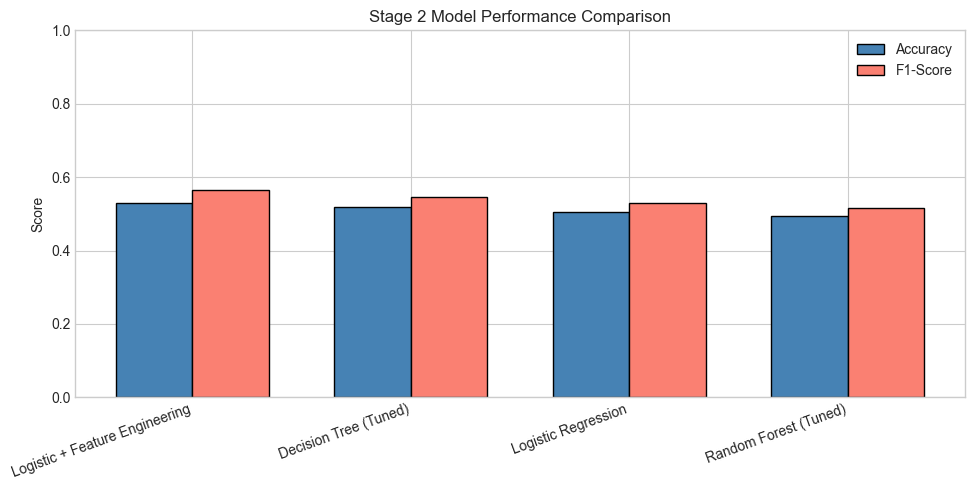

In [10]:
# Bar chart comparison
x = np.arange(len(results))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(x - width/2, results['Accuracy'], width, label='Accuracy', color='steelblue', edgecolor='black')
ax.bar(x + width/2, results['F1-Score'], width, label='F1-Score', color='salmon', edgecolor='black')

ax.set_xticks(x)
ax.set_xticklabels(results['Model'], rotation=20, ha='right')
ax.set_ylim(0, 1.0)
ax.set_ylabel('Score')
ax.set_title('Stage 2 Model Performance Comparison')
ax.legend()
plt.tight_layout()
plt.savefig(PLOT_DIR / 'plot_stage2_model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

Best model by F1-score: Logistic + Feature Engineering


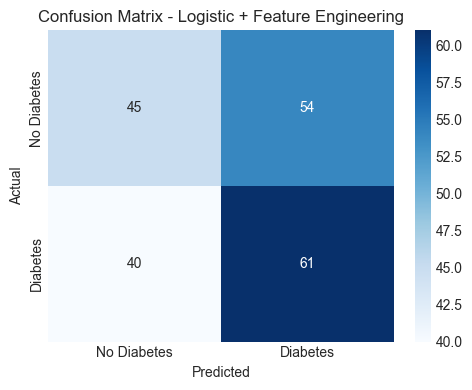


Classification Report for Best Model:
              precision    recall  f1-score   support

 No Diabetes       0.53      0.45      0.49        99
    Diabetes       0.53      0.60      0.56       101

    accuracy                           0.53       200
   macro avg       0.53      0.53      0.53       200
weighted avg       0.53      0.53      0.53       200



In [11]:
best_model_name = results.iloc[0]['Model']
print('Best model by F1-score:', best_model_name)

if best_model_name == 'Decision Tree (Tuned)':
    final_pred = dt_pred
elif best_model_name == 'Random Forest (Tuned)':
    final_pred = rf_pred
elif best_model_name == 'Logistic + Feature Engineering':
    final_pred = lr_fe_pred
else:
    final_pred = lr_pred

cm = confusion_matrix(y_test, final_pred)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Diabetes', 'Diabetes'],
            yticklabels=['No Diabetes', 'Diabetes'])
plt.title(f'Confusion Matrix - {best_model_name}')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.savefig(PLOT_DIR / 'plot_stage2_best_model_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nClassification Report for Best Model:')
print(classification_report(y_test, final_pred, target_names=['No Diabetes', 'Diabetes']))